# BigQuery Explorer

Query BigQuery tables and return results as pandas DataFrames.

In [ ]:
# Install dependencies (run once)
%pip install google-cloud-bigquery pandas db-dtypes pyarrow

In [1]:
from google.cloud import bigquery
import pandas as pd
import numpy as np

PROJECT = "realtime-headway-prediction"
client = bigquery.Client(project=PROJECT)
print(f"Connected to project: {client.project}")

Connected to project: realtime-headway-prediction


In [2]:
query = """
select
*
from `headway_prediction.clean`
where route_id in ('A', 'C', 'E')
  and direction = 'S'
"""

df = client.query(query).to_dataframe()
df.head()

,trip_uid,stop_id,track,trip_date,route_id,direction,arrival_time
0,1760340570_A..S58R,A02S,A3,2025-10-13 07:29:30+00:00,A,S,2025-10-13 11:29:30+00:00
1,1761211320_A..S51R,A02S,A3,2025-10-23 09:22:00+00:00,A,S,2025-10-23 13:22:29+00:00
2,1761069300_A..S57R,A02S,A3,2025-10-21 17:55:00+00:00,A,S,2025-10-21 21:56:09+00:00
3,1762237470_A..S58R,A02S,A3,2025-11-04 06:24:30+00:00,A,S,2025-11-04 11:26:11+00:00
4,1757057949_A..S57R,A02S,A3,2025-09-05 07:39:09+00:00,A,S,2025-09-05 11:39:40+00:00


In [3]:
# Quick summary of the returned data
print(f"Shape: {df.shape}")
df.info()


Shape: (4757706, 7)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4757706 entries, 0 to 4757705
Data columns (total 7 columns):
 #   Column        Dtype              
---  ------        -----              
 0   trip_uid      object             
 1   stop_id       object             
 2   track         object             
 3   trip_date     datetime64[us, UTC]
 4   route_id      object             
 5   direction     object             
 6   arrival_time  datetime64[us, UTC]
dtypes: datetime64[us, UTC](2), object(5)
memory usage: 254.1+ MB


### Validate Stops for Valid Routes

In [4]:
stops = pd.read_csv('../local_artifacts/raw_data/stops.txt')

### Handle missing data and define node order

In [5]:
# helper function to find routes with origin and terminal
# grouped by number of stops to help build topography in graph database

def route_finder(route, origin, terminal):
    df_a = df.loc[df['route_id']== route]

    # find trips with both origin and terminal
    trips_with_origin = (set(df_a.loc[df_a['stop_id']== origin, 'trip_uid']))
    trips_with_terminal = (set(df_a.loc[df_a['stop_id']== terminal, 'trip_uid']))

    matching_trips = trips_with_origin & trips_with_terminal # intersection

    # filter those trip_uids
    result = (df_a.loc[df_a['trip_uid'].isin(matching_trips)]
                 .groupby('trip_uid')['trip_uid']
                 .count()
                 .to_frame('counts')
                 .reset_index())

    return result

In [6]:
stops.loc[stops.stop_name.str.contains('World')]

,stop_id,stop_name,stop_lat,stop_lon,location_type,parent_station
858,E01,World Trade Center,40.712582,-74.009781,1.0,NaN
859,E01N,World Trade Center,40.712582,-74.009781,NaN,E01
860,E01S,World Trade Center,40.712582,-74.009781,NaN,E01


In [7]:
route, origin, terminal = 'E', 'G05S', 'E01S'

route_finder(route, origin, terminal)


,trip_uid,counts
0,1739769240_E..S04R,32
1,1739770380_E..S69R,22
2,1739771460_E..S69R,22
3,1739772300_E..S69R,22
4,1739773020_E..S69R,22
...,...,...
56491,1771299090_E..S04R,32
56492,1771300290_E..S04R,32
56493,1771301490_E..S04R,32
56494,1771302690_E..S04R,32


In [8]:
a_far_rockaway =  (
                        df.loc[df.trip_uid=='1747632300_A..S58R']
                        .sort_values(by=['arrival_time'], ascending=True)
                        #.merge(stops, on=['stop_id'], how='left')
                        ['stop_id']
                        .tolist()
                    )
a_far_rockaway

['A02S',
 'A03S',
 'A05S',
 'A06S',
 'A07S',
 'A09S',
 'A12S',
 'A15S',
 'A24S',
 'A27S',
 'A28S',
 'A31S',
 'A32S',
 'A34S',
 'A36S',
 'A38S',
 'A40S',
 'A41S',
 'A42S',
 'A46S',
 'A48S',
 'A51S',
 'A55S',
 'A57S',
 'A59S',
 'A60S',
 'A61S',
 'H02S',
 'H03S',
 'H04S',
 'H06S',
 'H07S',
 'H08S',
 'H09S',
 'H10S',
 'H11S']

In [9]:
a_lefferts =    (
                        df.loc[df.trip_uid=='1739773170_A..S57R']
                        .sort_values(by=['arrival_time'], ascending=True)
                        #.merge(stops, on=['stop_id'], how='left')
                        ['stop_id']
                        .tolist()
                        )
a_lefferts

['A02S',
 'A03S',
 'A05S',
 'A06S',
 'A07S',
 'A09S',
 'A12S',
 'A15S',
 'A24S',
 'A27S',
 'A28S',
 'A31S',
 'A32S',
 'A34S',
 'A36S',
 'A38S',
 'A40S',
 'A41S',
 'A42S',
 'A46S',
 'A48S',
 'A51S',
 'A55S',
 'A57S',
 'A59S',
 'A60S',
 'A61S',
 'A63S',
 'A64S',
 'A65S']

In [10]:
a_rockaway_park =    (
                        df.loc[df.trip_uid=='1754688720_A..S75R']
                        .sort_values(by=['arrival_time'], ascending=True)
                        #.merge(stops, on=['stop_id'], how='left')
                        ['stop_id']
                        .tolist()
                        )
a_rockaway_park

['A02S',
 'A03S',
 'A05S',
 'A06S',
 'A07S',
 'A09S',
 'A12S',
 'A15S',
 'A24S',
 'A27S',
 'A28S',
 'A31S',
 'A32S',
 'A34S',
 'A36S',
 'A38S',
 'A40S',
 'A41S',
 'A42S',
 'A46S',
 'A48S',
 'A51S',
 'A55S',
 'A57S',
 'A59S',
 'A60S',
 'A61S',
 'H02S',
 'H03S',
 'H04S',
 'H12S',
 'H13S',
 'H14S',
 'H15S']

In [11]:
tuid = "1739770740_C..S04R"
c_168_to_euclid = (
                        df.loc[df.trip_uid==tuid]
                        .sort_values(by=['arrival_time'], ascending=True)
                        .merge(stops, on=['stop_id'], how='left')
                        ['stop_id']
                        .tolist()
                        )

c_168_to_euclid

['A09S',
 'A10S',
 'A11S',
 'A12S',
 'A14S',
 'A15S',
 'A16S',
 'A17S',
 'A18S',
 'A19S',
 'A20S',
 'A21S',
 'A22S',
 'A24S',
 'A25S',
 'A27S',
 'A28S',
 'A30S',
 'A31S',
 'A32S',
 'A33S',
 'A34S',
 'A36S',
 'A38S',
 'A40S',
 'A41S',
 'A42S',
 'A43S',
 'A44S',
 'A45S',
 'A46S',
 'A47S',
 'A48S',
 'A49S',
 'A50S',
 'A51S',
 'A52S',
 'A53S',
 'A54S',
 'A55S']

In [12]:
tuid = "1739770380_E..S69R"
e_jamaica_wtc = (
                        df.loc[df.trip_uid==tuid]
                        .sort_values(by=['arrival_time'], ascending=True)
                        #.merge(stops, on=['stop_id'], how='left')
                        ['stop_id']
                        .tolist()
                        )
e_jamaica_wtc

['G05S',
 'G06S',
 'G07S',
 'F05S',
 'F06S',
 'F07S',
 'G08S',
 'G14S',
 'G21S',
 'F09S',
 'F11S',
 'F12S',
 'D14S',
 'A25S',
 'A27S',
 'A28S',
 'A30S',
 'A31S',
 'A32S',
 'A33S',
 'A34S',
 'E01S']

In [13]:
a_combined = sorted(set(a_far_rockaway + a_lefferts + a_rockaway_park))

a_combined

['A02S',
 'A03S',
 'A05S',
 'A06S',
 'A07S',
 'A09S',
 'A12S',
 'A15S',
 'A24S',
 'A27S',
 'A28S',
 'A31S',
 'A32S',
 'A34S',
 'A36S',
 'A38S',
 'A40S',
 'A41S',
 'A42S',
 'A46S',
 'A48S',
 'A51S',
 'A55S',
 'A57S',
 'A59S',
 'A60S',
 'A61S',
 'A63S',
 'A64S',
 'A65S',
 'H02S',
 'H03S',
 'H04S',
 'H06S',
 'H07S',
 'H08S',
 'H09S',
 'H10S',
 'H11S',
 'H12S',
 'H13S',
 'H14S',
 'H15S']

In [14]:
e_jamaica_wtc

['G05S',
 'G06S',
 'G07S',
 'F05S',
 'F06S',
 'F07S',
 'G08S',
 'G14S',
 'G21S',
 'F09S',
 'F11S',
 'F12S',
 'D14S',
 'A25S',
 'A27S',
 'A28S',
 'A30S',
 'A31S',
 'A32S',
 'A33S',
 'A34S',
 'E01S']

In [15]:
# raw sql data of actual train arrivals
arrivals = df[['trip_uid','stop_id','route_id','arrival_time','track']]

arrivals = arrivals.sort_values('arrival_time')

# 1 define the master topology
# create df of only the valid, scheduled route/stop combinations
valid_A_stops = a_combined
valid_C_stops = c_168_to_euclid
valid_E_stops = e_jamaica_wtc

valid_pairs = pd.DataFrame({
    'route_id':['A']*len(valid_A_stops) + ['C']*len(valid_C_stops) + ['E']*len(valid_E_stops),
    'stop_id': valid_A_stops + valid_C_stops + valid_E_stops
})

# filter raw data to only include these legist stops
arrivals = arrivals.merge(valid_pairs, on=['route_id','stop_id'], how='inner')


In [16]:
# ── Encode station_order from the route sequence lists ───────────────
# Build a (route_id, stop_id) → position mapping from each route's
# ordered stop list. Position 0 = first southbound stop (northernmost).

# A train: use far_rockaway as the trunk, then append branch-only stops
station_order_A = {stop: i for i, stop in enumerate(a_combined)}
station_order_C = {stop: i for i, stop in enumerate(c_168_to_euclid)}
station_order_E = {stop: i for i, stop in enumerate(e_jamaica_wtc)}

# Merge into a single lookup: (route_id, stop_id) → position
station_order_map = {}
for stop, pos in station_order_A.items():
    station_order_map[('A', stop)] = pos
for stop, pos in station_order_C.items():
    station_order_map[('C', stop)] = pos
for stop, pos in station_order_E.items():
    station_order_map[('E', stop)] = pos

# Map into the DataFrame
arrivals['station_order'] = arrivals.apply(
    lambda r: station_order_map.get((r['route_id'], r['stop_id']), -1), axis=1
)

# Verify no unmatched stops
unmatched = (arrivals['station_order'] == -1).sum()
print(f"Unmatched (route, stop) pairs: {unmatched}")

# Sort by route, geographic station order, then arrival time
arrivals = arrivals.sort_values(['route_id', 'station_order', 'arrival_time']).reset_index(drop=True)

print(f"\nStation order examples:")
print(arrivals[['route_id','stop_id','station_order','arrival_time']].drop_duplicates(['route_id','stop_id']).to_string())

Unmatched (route, stop) pairs: 0

Station order examples:
        route_id stop_id  station_order              arrival_time
0              A    A02S              0 2025-02-17 10:10:03+00:00
48790          A    A03S              1 2025-02-17 10:11:29+00:00
98784          A    A05S              2 2025-02-17 10:13:23+00:00
148783         A    A06S              3 2025-02-17 10:15:13+00:00
198787         A    A07S              4 2025-02-17 10:16:44+00:00
248798         A    A09S              5 2025-02-17 10:19:03+00:00
303390         A    A12S              6 2025-02-17 10:23:33+00:00
357791         A    A15S              7 2025-02-17 10:26:58+00:00
412232         A    A24S              8 2025-02-17 10:39:36+00:00
466736         A    A27S              9 2025-02-17 10:42:41+00:00
521225         A    A28S             10 2025-02-17 10:44:23+00:00
575710         A    A31S             11 2025-02-17 10:47:11+00:00
630196         A    A32S             12 2025-02-17 10:49:21+00:00
684685         A  

In [17]:
# ── Compute target: minutes_until_next_train ─────────────────────────
# Sort chronologically within each (route, station) group
arrivals = arrivals.sort_values(['route_id', 'stop_id', 'arrival_time']).reset_index(drop=True)

# Forward diff: next arrival time minus current arrival time
arrivals['minutes_until_next_train'] = (
    arrivals
    .groupby(['route_id', 'stop_id'])['arrival_time']
    .shift(-1)
    .sub(arrivals['arrival_time'])
    .dt.total_seconds() / 60.0
)

# Last arrival per group has no next train → NaN
print(f"Rows before dropping NaN targets: {len(arrivals):,}")
print(f"NaN targets (last per group):     {arrivals['minutes_until_next_train'].isna().sum():,}")
arrivals = arrivals.dropna(subset=['minutes_until_next_train']).reset_index(drop=True)
print(f"Rows after dropping NaN targets:  {len(arrivals):,}")

# Filter out overnight gaps and glitches
HEADWAY_MAX = 60  # minutes
print(f"\nTargets > {HEADWAY_MAX} min: {(arrivals['minutes_until_next_train'] > HEADWAY_MAX).sum():,}")
arrivals = arrivals.loc[arrivals['minutes_until_next_train'] > 0].reset_index(drop=True)  # remove zero/negative
arrivals = arrivals.loc[arrivals['minutes_until_next_train'] <= HEADWAY_MAX].reset_index(drop=True)
print(f"Rows after filtering:             {len(arrivals):,}")

print(f"\nTarget summary:\n{arrivals['minutes_until_next_train'].describe()}")

Rows before dropping NaN targets: 4,386,006
NaN targets (last per group):     105
Rows after dropping NaN targets:  4,385,901

Targets > 60 min: 20,574
Rows after filtering:             4,364,973

Target summary:
count    4.364973e+06
mean     1.005712e+01
std      6.132008e+00
min      1.666667e-02
25%      5.750000e+00
50%      8.950000e+00
75%      1.275000e+01
max      6.000000e+01
Name: minutes_until_next_train, dtype: float64


In [18]:
# ── Temporal features (NYC local time) ────────────────────────────────
import holidays

arrival_local = arrivals['arrival_time'].dt.tz_convert('America/New_York')
arrivals['hour'] = arrival_local.dt.hour
arrivals['day_of_week'] = arrival_local.dt.dayofweek  # 0=Mon, 6=Sun
arrivals['month'] = arrival_local.dt.month

# ── Cyclical encodings (sin/cos) ─────────────────────────────────────
# Daily periodicity (hour: period = 24)
arrivals['hour_sin'] = np.sin(2 * np.pi * arrivals['hour'] / 24)
arrivals['hour_cos'] = np.cos(2 * np.pi * arrivals['hour'] / 24)

# Weekly periodicity (day_of_week: period = 7)
arrivals['dow_sin'] = np.sin(2 * np.pi * arrivals['day_of_week'] / 7)
arrivals['dow_cos'] = np.cos(2 * np.pi * arrivals['day_of_week'] / 7)

# Monthly periodicity (month: period = 12)
arrivals['month_sin'] = np.sin(2 * np.pi * (arrivals['month'] - 1) / 12)
arrivals['month_cos'] = np.cos(2 * np.pi * (arrivals['month'] - 1) / 12)

# ── Binary flags ─────────────────────────────────────────────────────
arrivals['is_weekend'] = (arrivals['day_of_week'] >= 5).astype(int)

# US federal holidays via the `holidays` library
us_holidays = holidays.US(years=arrival_local.dt.year.unique().tolist())
arrivals['is_holiday'] = arrival_local.dt.date.map(lambda d: int(d in us_holidays))

# Summary
print(f"Cyclical features: hour_sin/cos, dow_sin/cos, month_sin/cos")
print(f"Binary flags: is_weekend={arrivals['is_weekend'].sum():,} rows,  is_holiday={arrivals['is_holiday'].sum():,} rows")
print(f"\nHolidays found in dataset:")
for d in sorted(set(arrival_local.dt.date[arrivals['is_holiday'] == 1])):
    print(f"  {d} — {us_holidays.get(d)}")

arrivals[['route_id','stop_id','arrival_time','hour','day_of_week','month',
          'hour_sin','hour_cos','dow_sin','dow_cos','is_weekend','is_holiday',
          'minutes_until_next_train']].head(10)

Cyclical features: hour_sin/cos, dow_sin/cos, month_sin/cos
Binary flags: is_weekend=901,779 rows,  is_holiday=123,227 rows

Holidays found in dataset:
  2025-02-17 — Washington's Birthday
  2025-05-26 — Memorial Day
  2025-06-19 — Juneteenth National Independence Day
  2025-07-04 — Independence Day
  2025-09-01 — Labor Day
  2025-10-13 — Columbus Day
  2025-11-11 — Veterans Day
  2025-11-27 — Thanksgiving
  2025-12-25 — Christmas Day
  2026-01-01 — New Year's Day
  2026-01-19 — Martin Luther King Jr. Day
  2026-02-16 — Washington's Birthday


,route_id,stop_id,arrival_time,hour,day_of_week,month,hour_sin,hour_cos,dow_sin,dow_cos,is_weekend,is_holiday,minutes_until_next_train
0,A,A02S,2025-02-17 10:10:03+00:00,5,0,2,0.965926,2.588190e-01,0.0,1.0,0,1,19.500000
1,A,A02S,2025-02-17 10:29:33+00:00,5,0,2,0.965926,2.588190e-01,0.0,1.0,0,1,18.716667
2,A,A02S,2025-02-17 10:48:16+00:00,5,0,2,0.965926,2.588190e-01,0.0,1.0,0,1,15.416667
3,A,A02S,2025-02-17 11:03:41+00:00,6,0,2,1.000000,6.123234e-17,0.0,1.0,0,1,15.816667
4,A,A02S,2025-02-17 11:19:30+00:00,6,0,2,1.000000,6.123234e-17,0.0,1.0,0,1,20.816667
5,A,A02S,2025-02-17 11:40:19+00:00,6,0,2,1.000000,6.123234e-17,0.0,1.0,0,1,9.183333
6,A,A02S,2025-02-17 11:49:30+00:00,6,0,2,1.000000,6.123234e-17,0.0,1.0,0,1,10.000000
7,A,A02S,2025-02-17 11:59:30+00:00,6,0,2,1.000000,6.123234e-17,0.0,1.0,0,1,10.250000
8,A,A02S,2025-02-17 12:09:45+00:00,7,0,2,0.965926,-2.588190e-01,0.0,1.0,0,1,9.850000
9,A,A02S,2025-02-17 12:19:36+00:00,7,0,2,0.965926,-2.588190e-01,0.0,1.0,0,1,9.900000


In [19]:
# ── Rolling regime features on target (no leakage) ───────────────────
# shift(1) excludes the current row's target from the window.
# min_periods=1 so early rows in each group get partial-window stats
# rather than NaN.

arrivals = arrivals.sort_values(['route_id', 'stop_id', 'arrival_time']).reset_index(drop=True)
grouped = arrivals.groupby(['route_id', 'stop_id'])['minutes_until_next_train']

# Window 3 — immediate signal
shifted = grouped.shift(1)
arrivals['rolling_mean_3']  = grouped.apply(lambda x: x.shift(1).rolling(3, min_periods=1).mean()).values
arrivals['rolling_std_3']   = grouped.apply(lambda x: x.shift(1).rolling(3, min_periods=1).std()).values

# Window 5 — short-term trend
arrivals['rolling_mean_5']  = grouped.apply(lambda x: x.shift(1).rolling(5, min_periods=1).mean()).values
arrivals['rolling_std_5']   = grouped.apply(lambda x: x.shift(1).rolling(5, min_periods=1).std()).values

# Window 10 — regime-level context
arrivals['rolling_mean_10'] = grouped.apply(lambda x: x.shift(1).rolling(10, min_periods=1).mean()).values
arrivals['rolling_max_10']  = grouped.apply(lambda x: x.shift(1).rolling(10, min_periods=1).max()).values

# Fill remaining NaN (first row per group has no prior observation)
for col in ['rolling_std_3', 'rolling_std_5']:
    arrivals[col] = arrivals[col].fillna(0)

print("Rolling features added:")
print(arrivals[['route_id','stop_id','minutes_until_next_train',
                'rolling_mean_3','rolling_std_3',
                'rolling_mean_5','rolling_std_5',
                'rolling_mean_10','rolling_max_10']].head(15))

print(f"\nNaN counts:")
for col in ['rolling_mean_3','rolling_std_3','rolling_mean_5','rolling_std_5','rolling_mean_10','rolling_max_10']:
    print(f"  {col}: {arrivals[col].isna().sum()}")

Rolling features added:
   route_id stop_id  minutes_until_next_train  rolling_mean_3  rolling_std_3  \
0         A    A02S                 19.500000             NaN       0.000000   
1         A    A02S                 18.716667       19.500000       0.000000   
2         A    A02S                 15.416667       19.108333       0.553900   
3         A    A02S                 15.816667       17.877778       2.167073   
4         A    A02S                 20.816667       16.650000       1.800926   
5         A    A02S                  9.183333       17.350000       3.008876   
6         A    A02S                 10.000000       15.272222       5.835746   
7         A    A02S                 10.250000       13.333333       6.493608   
8         A    A02S                  9.850000        9.811111       0.557856   
9         A    A02S                  9.900000       10.033333       0.202073   
10        A    A02S                 11.166667       10.000000       0.217945   
11        A    A

In [20]:
# ── Fill remaining NaN in rolling features (first row per group) ─────
# Use per-group mean as fill so we don't leak cross-group info.
rolling_cols = ['rolling_mean_3', 'rolling_std_3',
                'rolling_mean_5', 'rolling_std_5',
                'rolling_mean_10', 'rolling_max_10']

for col in rolling_cols:
    group_means = arrivals.groupby(['route_id', 'stop_id'])[col].transform('mean')
    arrivals[col] = arrivals[col].fillna(group_means)

print("NaN counts after fill:")
for col in rolling_cols:
    print(f"  {col}: {arrivals[col].isna().sum()}")

print(f"\nFinal shape: {arrivals.shape}")
print(f"Columns: {list(arrivals.columns)}")

NaN counts after fill:
  rolling_mean_3: 0
  rolling_std_3: 0
  rolling_mean_5: 0
  rolling_std_5: 0
  rolling_mean_10: 0
  rolling_max_10: 0

Final shape: (4364973, 24)
Columns: ['trip_uid', 'stop_id', 'route_id', 'arrival_time', 'track', 'station_order', 'minutes_until_next_train', 'hour', 'day_of_week', 'month', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos', 'is_weekend', 'is_holiday', 'rolling_mean_3', 'rolling_std_3', 'rolling_mean_5', 'rolling_std_5', 'rolling_mean_10', 'rolling_max_10']


In [21]:
# ── group_id and time_idx (required by TFT) ──────────────────────────
# group_id: unique string identifier per time series (route_id + stop_id)
# time_idx:  sequential integer index within each group, ordered by arrival_time

arrivals = arrivals.sort_values(['route_id', 'stop_id', 'arrival_time']).reset_index(drop=True)

arrivals['group_id'] = arrivals['route_id'] + '_' + arrivals['stop_id']
arrivals['time_idx'] = arrivals.groupby('group_id').cumcount()

print(f"Unique groups: {arrivals['group_id'].nunique()}")
print(f"time_idx range per group:")
print(arrivals.groupby('group_id')['time_idx'].agg(['min','max','count']).describe())
print(f"\nSample:")
print(arrivals[['group_id','time_idx','route_id','stop_id','arrival_time','minutes_until_next_train']].head(10))

Unique groups: 105
time_idx range per group:
         min           max         count
count  105.0    105.000000    105.000000
mean     0.0  41570.171429  41571.171429
std      0.0  14842.620242  14842.620242
min      0.0   1185.000000   1186.000000
25%      0.0  33534.000000  33535.000000
50%      0.0  34673.000000  34674.000000
75%      0.0  54599.000000  54600.000000
max      0.0  61742.000000  61743.000000

Sample:
  group_id  time_idx route_id stop_id              arrival_time  \
0   A_A02S         0        A    A02S 2025-02-17 10:10:03+00:00   
1   A_A02S         1        A    A02S 2025-02-17 10:29:33+00:00   
2   A_A02S         2        A    A02S 2025-02-17 10:48:16+00:00   
3   A_A02S         3        A    A02S 2025-02-17 11:03:41+00:00   
4   A_A02S         4        A    A02S 2025-02-17 11:19:30+00:00   
5   A_A02S         5        A    A02S 2025-02-17 11:40:19+00:00   
6   A_A02S         6        A    A02S 2025-02-17 11:49:30+00:00   
7   A_A02S         7        A    A02S 202

In [22]:
# ── Empirical median headway (known covariate) ───────────────────────
# Median headway by (route_id, is_weekend, hour), computed from TRAIN period only.
# This acts as a "what's normal right now" baseline the model can learn deviations from.

TRAIN_CUTOFF = pd.Timestamp('2025-10-29', tz='UTC')

train_mask = arrivals['arrival_time'] < TRAIN_CUTOFF
empirical_lookup = (
    arrivals.loc[train_mask]
    .groupby(['route_id', 'is_weekend', 'hour'])['minutes_until_next_train']
    .median()
    .rename('empirical_median')
)

arrivals = arrivals.merge(
    empirical_lookup,
    on=['route_id', 'is_weekend', 'hour'],
    how='left',
)

# Fill any (route, weekend, hour) combos that only appear in val/test with
# the global train median as fallback
global_median = arrivals.loc[train_mask, 'minutes_until_next_train'].median()
arrivals['empirical_median'] = arrivals['empirical_median'].fillna(global_median)

print(f'Empirical median lookup: {len(empirical_lookup)} entries')
print(f'NaN after merge (filled with global median {global_median:.2f}): '
      f'{arrivals["empirical_median"].isna().sum()}')
print(f'\nCorrelation with target: '
      f'{arrivals["empirical_median"].corr(arrivals["minutes_until_next_train"]):.4f}')
print(f'\nSample:')
print(arrivals[['route_id', 'is_weekend', 'hour', 'empirical_median',
                'minutes_until_next_train']].sample(10, random_state=42))

Empirical median lookup: 135 entries
NaN after merge (filled with global median 8.85): 0

Correlation with target: 0.5592

Sample:
        route_id  is_weekend  hour  empirical_median  minutes_until_next_train
2461913        C           0    16          9.500000                 10.600000
610929         A           0    14          8.000000                  6.000000
2593703        C           1    11         12.166667                  5.316667
1292544        A           0    13          8.633333                 11.083333
2766065        C           0    10          8.250000                  8.183333
3586630        E           0     8          4.750000                  6.950000
2007423        C           0    18          9.250000                  7.083333
1251900        A           0     9          6.266667                  5.916667
2809395        C           1     9         12.000000                 18.250000
3356127        E           0     7          4.733333                  3.250000


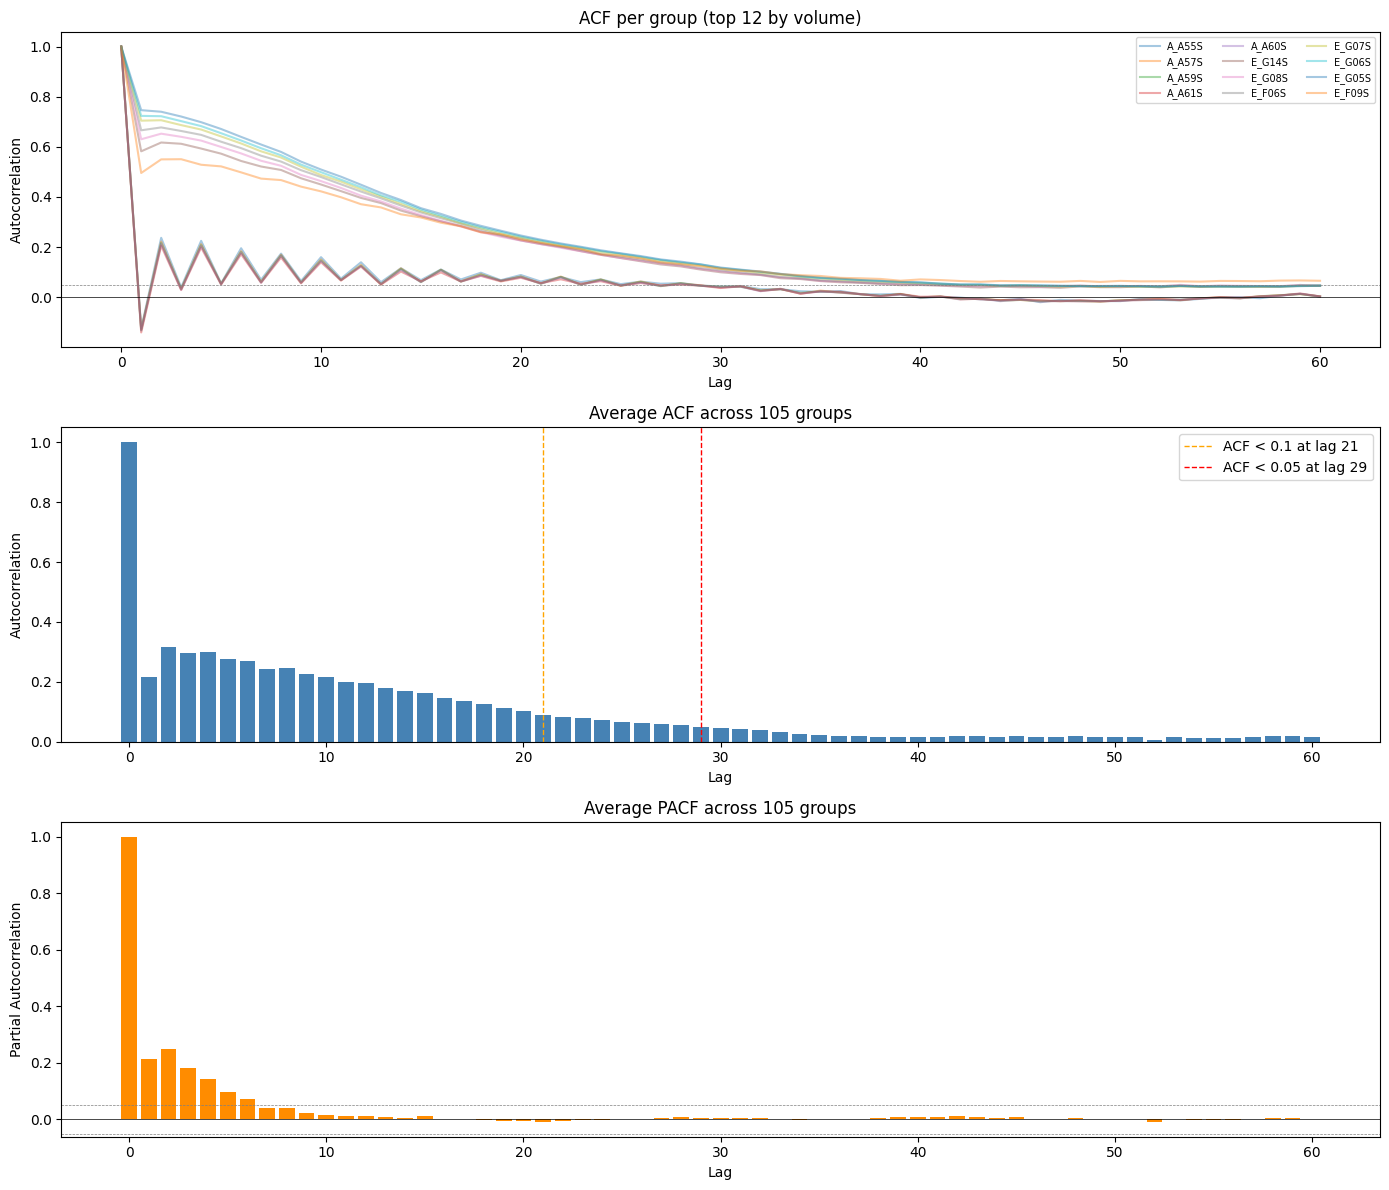


── Lookback window guidance ──
Average ACF values at key lags:
  lag   1: ACF=0.2154  PACF=0.2154
  lag   3: ACF=0.2954  PACF=0.1827
  lag   5: ACF=0.2747  PACF=0.0988
  lag  10: ACF=0.2161  PACF=0.0161
  lag  15: ACF=0.1635  PACF=0.0128
  lag  20: ACF=0.1013  PACF=-0.0060
  lag  30: ACF=0.0470  PACF=0.0048
  lag  40: ACF=0.0151  PACF=0.0074
  lag  50: ACF=0.0159  PACF=0.0012
  lag  60: ACF=0.0166  PACF=0.0014
  Average ACF < 0.10 at lag 21
  Average ACF < 0.05 at lag 29
  Average ACF < 0.02 at lag 36


In [23]:
# ── Autocorrelation analysis to determine lookback window ─────────────
from statsmodels.tsa.stattools import acf, pacf
import matplotlib.pyplot as plt

MAX_LAGS = 60  # examine up to 60 steps back

# Compute ACF/PACF per group, then average across groups for a robust signal.
# Sample a representative set of groups (one per route + a few high-volume ones).
sample_groups = (
    arrivals.groupby('group_id')['time_idx']
    .count()
    .sort_values(ascending=False)
    .head(12)
    .index.tolist()
)

fig, axes = plt.subplots(3, 1, figsize=(14, 12))

# ── 1. Per-group ACF overlay ─────────────────────────────────────────
ax = axes[0]
for gid in sample_groups:
    series = arrivals.loc[arrivals['group_id'] == gid, 'minutes_until_next_train'].values
    acf_vals = acf(series, nlags=MAX_LAGS, fft=True)
    ax.plot(range(MAX_LAGS + 1), acf_vals, alpha=0.4, label=gid)
ax.axhline(0, color='k', linewidth=0.5)
ax.axhline(0.05, color='grey', linestyle='--', linewidth=0.5)
ax.set_title('ACF per group (top 12 by volume)')
ax.set_xlabel('Lag')
ax.set_ylabel('Autocorrelation')
ax.legend(fontsize=7, ncol=3, loc='upper right')

# ── 2. Average ACF across ALL groups ─────────────────────────────────
ax = axes[1]
all_acfs = []
for gid, grp in arrivals.groupby('group_id'):
    series = grp['minutes_until_next_train'].values
    if len(series) > MAX_LAGS + 1:
        all_acfs.append(acf(series, nlags=MAX_LAGS, fft=True))

avg_acf = np.mean(all_acfs, axis=0)
ax.bar(range(MAX_LAGS + 1), avg_acf, color='steelblue', width=0.8)
ax.axhline(0, color='k', linewidth=0.5)
ax.set_title(f'Average ACF across {len(all_acfs)} groups')
ax.set_xlabel('Lag')
ax.set_ylabel('Autocorrelation')

# Annotate where ACF drops below thresholds
for thresh in [0.1, 0.05]:
    below = np.where(avg_acf[1:] < thresh)[0]
    if len(below) > 0:
        lag_at = below[0] + 1
        ax.axvline(lag_at, color='red' if thresh == 0.05 else 'orange',
                    linestyle='--', linewidth=1, label=f'ACF < {thresh} at lag {lag_at}')
ax.legend()

# ── 3. Average PACF across ALL groups ────────────────────────────────
ax = axes[2]
all_pacfs = []
for gid, grp in arrivals.groupby('group_id'):
    series = grp['minutes_until_next_train'].values
    if len(series) > MAX_LAGS + 1:
        try:
            all_pacfs.append(pacf(series, nlags=MAX_LAGS))
        except Exception:
            pass

avg_pacf = np.mean(all_pacfs, axis=0)
ax.bar(range(MAX_LAGS + 1), avg_pacf, color='darkorange', width=0.8)
ax.axhline(0, color='k', linewidth=0.5)
ax.axhline(0.05, color='grey', linestyle='--', linewidth=0.5)
ax.axhline(-0.05, color='grey', linestyle='--', linewidth=0.5)
ax.set_title(f'Average PACF across {len(all_pacfs)} groups')
ax.set_xlabel('Lag')
ax.set_ylabel('Partial Autocorrelation')

plt.tight_layout()
plt.show()

# ── Summary stats ────────────────────────────────────────────────────
print("\n── Lookback window guidance ──")
print(f"Average ACF values at key lags:")
for lag in [1, 3, 5, 10, 15, 20, 30, 40, 50, 60]:
    if lag <= MAX_LAGS:
        print(f"  lag {lag:3d}: ACF={avg_acf[lag]:.4f}  PACF={avg_pacf[lag]:.4f}")

# Find where average ACF drops below thresholds
for thresh_name, thresh in [("0.10", 0.10), ("0.05", 0.05), ("0.02", 0.02)]:
    below = np.where(avg_acf[1:] < float(thresh_name))[0]
    if len(below) > 0:
        print(f"  Average ACF < {thresh_name} at lag {below[0] + 1}")
    else:
        print(f"  Average ACF never drops below {thresh_name} within {MAX_LAGS} lags")

In [24]:
# ── Save to parquet ──────────────────────────────────────────────────
import os

out_dir = '../local_artifacts/processed_data'
os.makedirs(out_dir, exist_ok=True)

out_path = os.path.join(out_dir, 'tft_training_data.parquet')
arrivals.to_parquet(out_path, index=False, engine='pyarrow')

print(f"Saved {len(arrivals):,} rows → {out_path}")
print(f"File size: {os.path.getsize(out_path) / 1e6:.1f} MB")

Saved 4,364,973 rows → ../local_artifacts/processed_data/tft_training_data.parquet
File size: 192.2 MB
